# Computer Vision 1: Assignment 3

Task 2

Group Number 43

Marek Drwal

15.12.2025

## setup

In [285]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

## defs

In [286]:
def show_img(img, pth='', comment='', show=True):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    if show:
        plt.show()

In [287]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [288]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [289]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [290]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## imgs

In [291]:
pth = 'yellow_horizon.jpg'

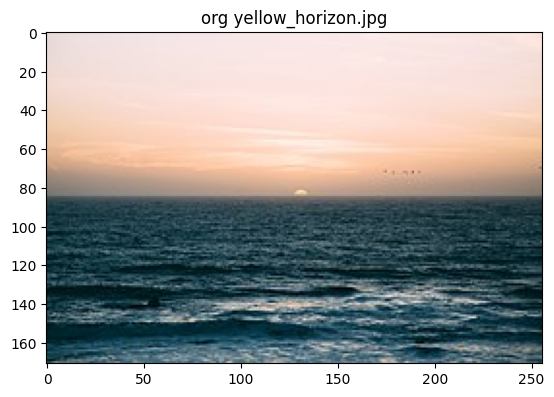

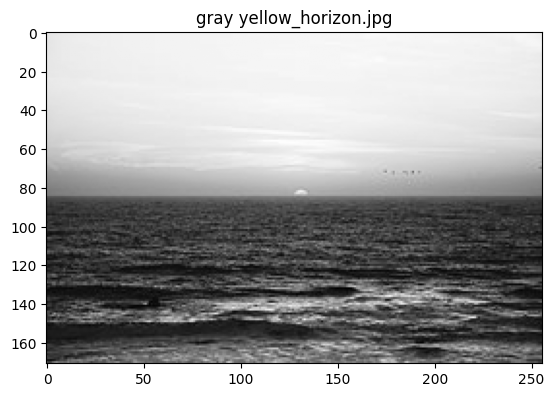

In [292]:
img = load_display_img(pth)

## Sobel

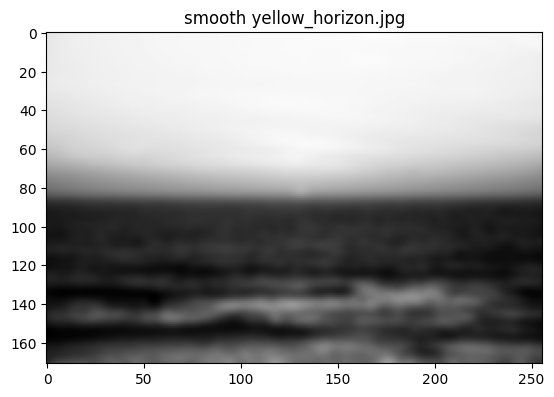

In [293]:
smooth_img = ski.filters.gaussian(img, 2.5, preserve_range=True)
show_img(smooth_img, pth, 'smooth')

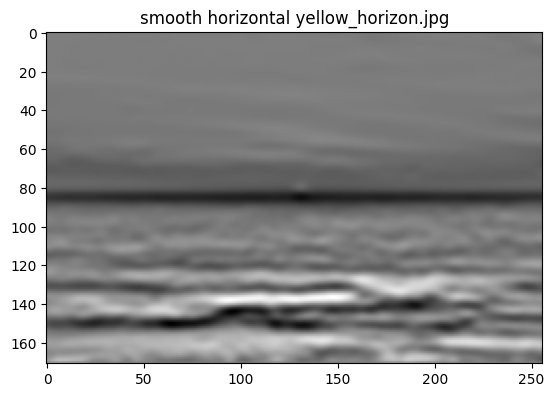

In [294]:
h_img = ski.filters.sobel_h(smooth_img)
show_img(h_img, pth, 'smooth horizontal')

## candidate pts

In [295]:
min_gradient_row_indices = np.argmin(h_img, axis=0)
min_gradient_row_indices.shape

(256,)

In [302]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    y = min_gradient_row_indices[x]
    pts[y,x] = 1
    print(x, y, end=', ')
    xs.append(x)
    ys.append(y)

0 85, 12 85, 24 150, 36 85, 48 85, 60 150, 72 150, 84 149, 96 144, 108 85, 120 150, 132 85, 144 85, 156 85, 168 85, 180 85, 192 141, 204 85, 216 85, 228 85, 240 85, 252 85, 

In [297]:
len(ys)

22

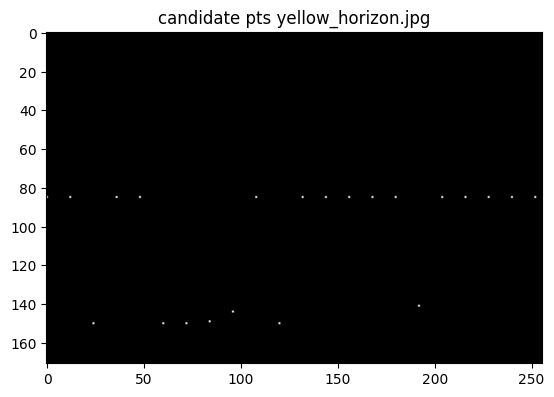

In [298]:
show_img(pts, pth, 'candidate pts')

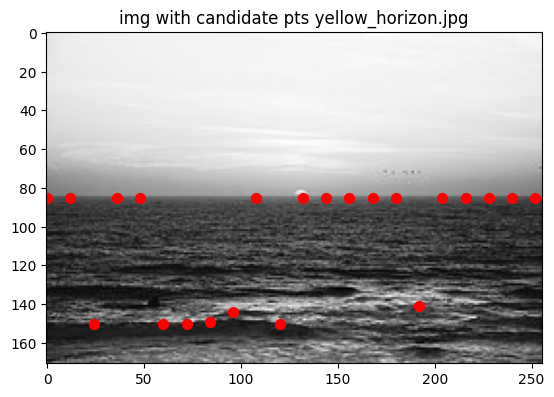

In [299]:
show_img(img, pth, 'img with candidate pts', False)
plt.scatter(xs, ys, c='red', s=50)
plt.show()

## RANSAC

In [303]:
rr = RANSACRegressor()
rr

RANSACRegressor()

In [308]:
rr.fit(np.array(list(zip(xs,ys))), ys)
rr

RANSACRegressor()

In [309]:
yy = rr.predict(np.array(list(zip(xs,ys))))
yy

array([ 85.,  85., 150.,  85.,  85., 150., 150., 149., 144.,  85., 150.,
        85.,  85.,  85.,  85.,  85., 141.,  85.,  85.,  85.,  85.,  85.])

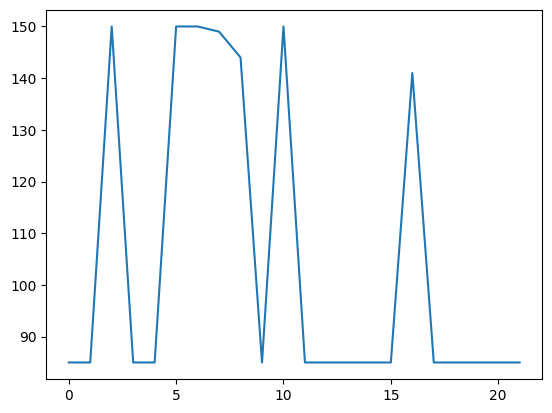

In [312]:
plt.plot(yy)